# O6-Multimodal RF-policy analytics

This notebook compares the 100-tree fixed SMAC baseline with the two RWTHGPT
policies in dimensions 50 and 100. The initial-choice policy asks the model for
one setting before the first evaluation; the dynamic policy asks at trials 100,
250, and 500. Lower objective values are better. Incomplete jobs are reported
in the coverage table and excluded from performance rankings.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
HERE = Path.cwd()
if HERE.name != '40_llm_o6':
    HERE = Path('experiments/synthaticBench/o6_multi_modal/depth_policies/40_llm_o6').resolve()
ROOT = HERE / 'results'
DIMENSIONS = (50, 100)
FIXED_SEEDS = tuple(range(6))
MODELS = {
    'gpt-5.4-mini': tuple(range(6)),
    'gpt-5.5': (0, 1, 2),
}
POLICY_SPECS = [
    ('Fixed 100 trees', 'fixed_100_trees', None, FIXED_SEEDS),
    ('Initial GPT-5.4-mini', 'initial_choice', 'gpt-5.4-mini', MODELS['gpt-5.4-mini']),
    ('Initial GPT-5.5', 'initial_choice', 'gpt-5.5', MODELS['gpt-5.5']),
    ('Dynamic GPT-5.4-mini', 'dynamic', 'gpt-5.4-mini', MODELS['gpt-5.4-mini']),
    ('Dynamic GPT-5.5', 'dynamic', 'gpt-5.5', MODELS['gpt-5.5']),
]
N_TRIALS = 1000
print(f'Results root: {ROOT}')

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/home/io632776/work/py-envs/aclib2-surrogates-py39/lib64/pyt

Results root: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/40_llm_o6/results


## Coverage and loading

The expected grid contains 48 runs: 12 fixed, 18 initial-choice, and 18
dynamic. The loader reads the completion marker even when a trajectory is not
available yet, so this cell is also a progress monitor.

In [2]:
def model_suffix(model):
    return model.replace('.', '_').replace('-', '_') if model else None


def run_directory(dimension, kind, model, seed):
    name = kind if model is None else f'{kind}_{model_suffix(model)}'
    return ROOT / f'dimension_{dimension}' / 'benchmark_seed_52' / name / str(seed)


def failed_evaluations(run_dir):
    path = run_dir / 'runhistory.json'
    if not path.exists():
        return 0
    try:
        data = json.loads(path.read_text())
        return sum(not np.isfinite(float(entry.get('cost', np.nan))) for entry in data.get('data', []))
    except (OSError, TypeError, ValueError, json.JSONDecodeError):
        return np.nan


expected_rows, run_rows = [], []
for dimension in DIMENSIONS:
    for label, kind, model, seeds in POLICY_SPECS:
        for seed in seeds:
            run_dir = run_directory(dimension, kind, model, seed)
            completion_path = run_dir / 'completed.json'
            trajectory_path = run_dir / 'trajectory.json'
            completion = json.loads(completion_path.read_text()) if completion_path.exists() else {}
            payload = json.loads(trajectory_path.read_text()) if trajectory_path.exists() else None
            status = 'complete' if payload is not None else completion.get('state', 'missing')
            row = dict(dimension=dimension, policy=label, kind=kind, model=model,
                       smac_seed=seed, status=status, trials=0,
                       failed_evaluations=failed_evaluations(run_dir), final=np.nan,
                       run_dir=str(run_dir), payload=payload)
            if payload is not None:
                row['trials'] = len(payload.get('iteration', []))
                best = payload.get('best_so_far', [])
                row['final'] = float(best[-1]) if best else np.nan
            expected_rows.append({k: row[k] for k in ('dimension', 'policy', 'smac_seed')})
            run_rows.append(row)

coverage = pd.DataFrame(run_rows)
display(coverage.drop(columns='payload').sort_values(['dimension', 'policy', 'smac_seed']))
display(coverage.groupby(['dimension', 'policy', 'status']).size().rename('runs').reset_index())
print(f'Complete trajectories: {(coverage.status == "complete").sum()} / {len(coverage)}')

,dimension,policy,kind,model,smac_seed,status,trials,failed_evaluations,final,run_dir
15,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,0,complete,1000,0,535.482813,/rwthfs/rz/cluster/home/io632776/experiments/a...
16,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,1,complete,1000,0,627.757936,/rwthfs/rz/cluster/home/io632776/experiments/a...
17,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,2,complete,1000,0,495.756578,/rwthfs/rz/cluster/home/io632776/experiments/a...
18,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,3,complete,1000,0,561.381498,/rwthfs/rz/cluster/home/io632776/experiments/a...
19,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,4,complete,1000,0,550.027151,/rwthfs/rz/cluster/home/io632776/experiments/a...
20,50,Dynamic GPT-5.4-mini,dynamic,gpt-5.4-mini,5,complete,1000,0,603.987489,/rwthfs/rz/cluster/home/io632776/experiments/a...
21,50,Dynamic GPT-5.5,dynamic,gpt-5.5,0,complete,1000,0,541.364800,/rwthfs/rz/cluster/home/io632776/experiments/a...
22,50,Dynamic GPT-5.5,dynamic,gpt-5.5,1,complete,1000,0,579.462625,/rwthfs/rz/cluster/home/io632776/experiments/a...
23,50,Dynamic GPT-5.5,dynamic,gpt-5.5,2,complete,1000,0,483.143437,/rwthfs/rz/cluster/home/io632776/experiments/a...
0,50,Fixed 100 trees,fixed_100_trees,None,0,complete,1000,0,508.179699,/rwthfs/rz/cluster/home/io632776/experiments/a...


,dimension,policy,status,runs
0,50,Dynamic GPT-5.4-mini,complete,6
1,50,Dynamic GPT-5.5,complete,3
2,50,Fixed 100 trees,complete,6
3,50,Initial GPT-5.4-mini,complete,6
4,50,Initial GPT-5.5,complete,3
5,100,Dynamic GPT-5.4-mini,complete,6
6,100,Dynamic GPT-5.5,complete,2
7,100,Dynamic GPT-5.5,running,1
8,100,Fixed 100 trees,complete,6
9,100,Initial GPT-5.4-mini,complete,6


Complete trajectories: 47 / 48


## Final-incumbent rankings

Only complete trajectories with 1,000 trials are used. For each dimension,
policies are ranked by their mean final incumbent objective across their
available SMAC seeds. The final table averages those ranks across dimensions;
it also reports how many dimensions are currently available.

In [3]:
complete = coverage[(coverage.status == 'complete') & (coverage.trials == N_TRIALS)].copy()
ranking = (complete.groupby(['dimension', 'policy'])
           .agg(average_final=('final', 'mean'), std_final=('final', 'std'), runs=('final', 'size'))
           .reset_index())
if len(ranking):
    ranking['rank'] = (ranking.groupby('dimension')['average_final']
                       .rank(method='min', ascending=True).astype(int))
    ranking = ranking.sort_values(['dimension', 'rank', 'policy'])
    display(ranking)
    average_rank = (ranking.groupby('policy')
                    .agg(average_rank=('rank', 'mean'), dimensions_ranked=('dimension', 'nunique'),
                         mean_final=('average_final', 'mean'))
                    .reset_index().sort_values(['average_rank', 'policy']))
    display(average_rank)
else:
    print('No complete 1,000-trial trajectories yet.')

,dimension,policy,average_final,std_final,runs,rank
2,50,Fixed 100 trees,477.469157,75.442903,6,1
4,50,Initial GPT-5.5,498.060048,106.126098,3,2
1,50,Dynamic GPT-5.5,534.656954,48.508689,3,3
0,50,Dynamic GPT-5.4-mini,562.398911,47.583998,6,4
3,50,Initial GPT-5.4-mini,629.172095,81.804451,6,5
9,100,Initial GPT-5.5,1623.542015,83.128151,3,1
7,100,Fixed 100 trees,1651.265540,65.545237,6,2
5,100,Dynamic GPT-5.4-mini,1683.438642,112.243682,6,3
8,100,Initial GPT-5.4-mini,1755.121486,109.783472,6,4
6,100,Dynamic GPT-5.5,1795.086180,124.335330,2,5


,policy,average_rank,dimensions_ranked,mean_final
2,Fixed 100 trees,1.5,2,1064.367348
4,Initial GPT-5.5,1.5,2,1060.801031
0,Dynamic GPT-5.4-mini,3.5,2,1122.918776
1,Dynamic GPT-5.5,4.0,2,1164.871567
3,Initial GPT-5.4-mini,4.5,2,1192.146790


## Trajectory comparison

For every dimension, the lines show the mean best-so-far objective across
completed seeds. Shaded regions show ± one standard error. The plot updates as
the arrays finish.

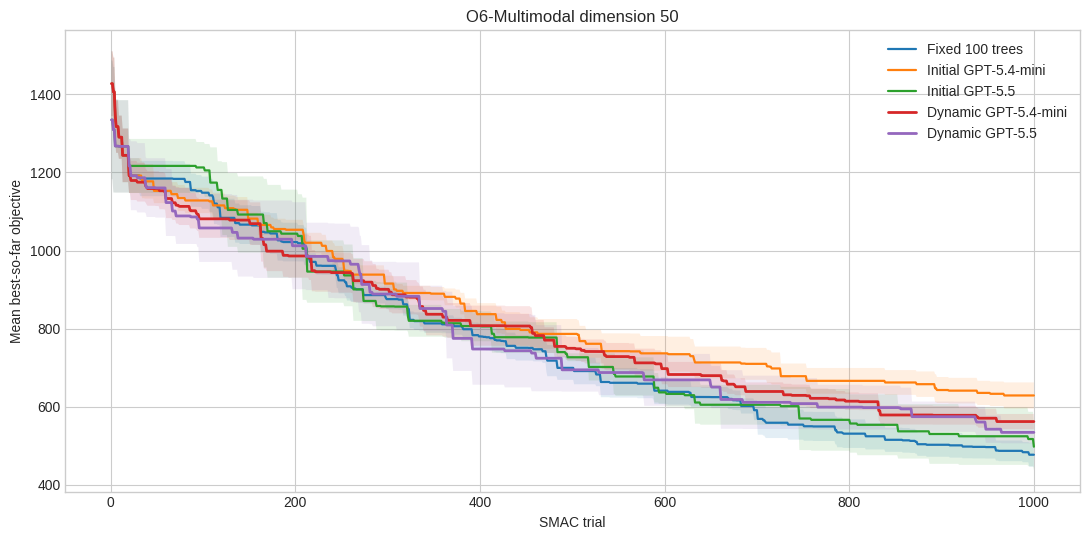

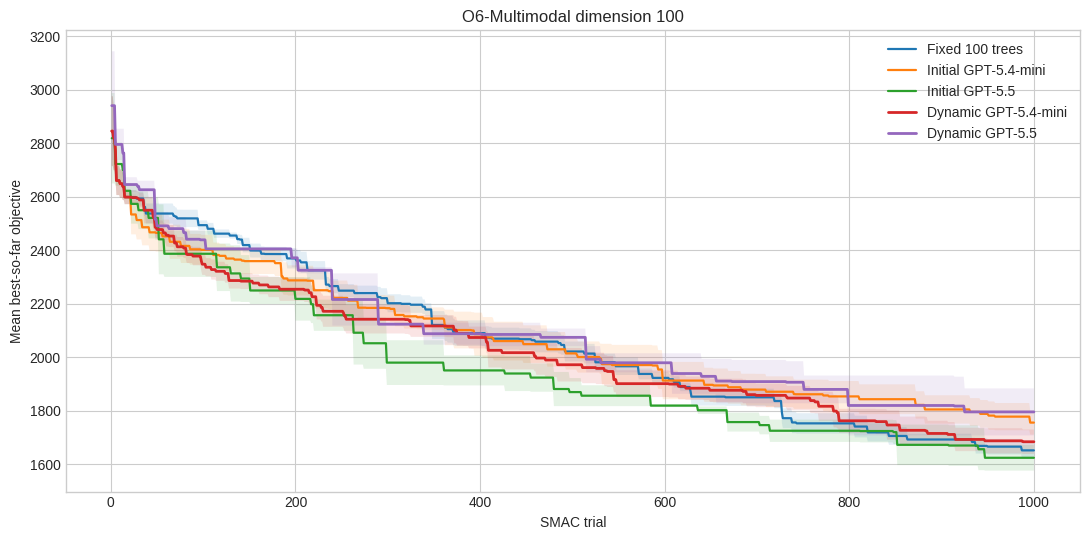

In [4]:
for dimension in DIMENSIONS:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    plotted = False
    for label, *_ in POLICY_SPECS:
        selected = complete[(complete.dimension == dimension) & (complete.policy == label)]
        curves = [np.asarray(row.payload['best_so_far'], dtype=float) for row in selected.itertuples()]
        if not curves or min(map(len, curves)) < 2:
            continue
        n = min(map(len, curves))
        values = np.vstack([curve[:n] for curve in curves])
        mean = values.mean(axis=0)
        se = values.std(axis=0, ddof=1) / math.sqrt(len(values)) if len(values) > 1 else np.zeros(n)
        x = np.arange(1, n + 1)
        ax.plot(x, mean, label=label, linewidth=2 if 'Dynamic' in label else 1.6)
        ax.fill_between(x, mean - se, mean + se, alpha=0.12)
        plotted = True
    ax.set(title=f'O6-Multimodal dimension {dimension}', xlabel='SMAC trial',
           ylabel='Mean best-so-far objective')
    if plotted:
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No complete trajectories yet', ha='center', va='center', transform=ax.transAxes)
    plt.tight_layout(); plt.show()

## LLM RF settings and token usage

The initial settings come from each run identity. Dynamic settings are read
from the callback audit, including checkpoint, chosen RF values, confidence,
and token usage.

In [5]:
decision_rows = []
for row in coverage.itertuples():
    payload = row.payload
    if payload is None:
        continue
    if row.kind == 'initial_choice':
        settings = payload.get('initial_choice', {}).get('settings', payload.get('rf_settings', {}))
        decision_rows.append(dict(dimension=row.dimension, policy=row.policy, model=row.model,
                                  smac_seed=row.smac_seed, checkpoint=0, **settings))
    elif row.kind == 'dynamic':
        decisions = payload.get('llm_policy', {}).get('decisions', {})
        for checkpoint, decision in decisions.items():
            settings = decision.get('settings', {})
            usage = decision.get('usage') or {}
            decision_rows.append(dict(dimension=row.dimension, policy=row.policy, model=row.model,
                                      smac_seed=row.smac_seed, checkpoint=int(checkpoint),
                                      actual_completed_trials=decision.get('actual_completed_trials_at_call'),
                                      input_tokens=usage.get('input_tokens'), output_tokens=usage.get('output_tokens'),
                                      **settings))
decisions = pd.DataFrame(decision_rows)
if len(decisions):
    display(decisions.sort_values(['dimension', 'policy', 'smac_seed', 'checkpoint']))
    setting_columns = ['n_trees', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'feature_ratio']
    display(decisions.groupby(['dimension', 'policy', 'checkpoint'])[setting_columns].mean().round(3))
else:
    print('No LLM decisions have been recorded yet.')

,dimension,policy,model,smac_seed,checkpoint,feature_ratio,max_depth,min_samples_leaf,min_samples_split,n_trees,actual_completed_trials,input_tokens,output_tokens
9,50,Dynamic GPT-5.4-mini,gpt-5.4-mini,0,100,1.00,12,1,2,50,103.0,NaN,NaN
10,50,Dynamic GPT-5.4-mini,gpt-5.4-mini,0,250,0.90,16,2,2,100,250.0,NaN,NaN
11,50,Dynamic GPT-5.4-mini,gpt-5.4-mini,0,500,0.80,14,2,2,100,503.0,NaN,NaN
12,50,Dynamic GPT-5.4-mini,gpt-5.4-mini,1,100,0.90,24,2,2,25,100.0,NaN,NaN
13,50,Dynamic GPT-5.4-mini,gpt-5.4-mini,1,250,0.80,30,1,2,50,250.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40,100,Initial GPT-5.4-mini,gpt-5.4-mini,4,0,0.30,12,1,2,50,NaN,NaN,NaN
41,100,Initial GPT-5.4-mini,gpt-5.4-mini,5,0,0.30,30,1,2,100,NaN,NaN,NaN
42,100,Initial GPT-5.5,gpt-5.5,0,0,0.33,30,2,4,100,NaN,NaN,NaN
43,100,Initial GPT-5.5,gpt-5.5,1,0,0.33,20,3,4,100,NaN,NaN,NaN


n_trees  max_depth  \
dimension policy               checkpoint                       
50        Dynamic GPT-5.4-mini 100          32.500     15.333   
                               250          61.667     17.667   
                               500          74.167     18.000   
          Dynamic GPT-5.5      100          74.667     21.333   
                               250          98.667     23.333   
                               500         100.000     26.000   
          Initial GPT-5.4-mini 0            59.333     13.667   
          Initial GPT-5.5      0           100.000     26.667   
100       Dynamic GPT-5.4-mini 100          32.500     20.000   
                               250          53.333     19.667   
                               500          68.333     19.667   
          Dynamic GPT-5.5      100          80.000     17.000   
                               250         100.000     20.000   
                               500         100.000     23.000   
          Initial GPT-5.4-mini 0            65.333     16.167   
          Initial GPT-5.5      0           100.000     25.000   

                                           min_samples_split  \
dimension policy               checkpoint                      
50        Dynamic GPT-5.4-mini 100                     2.333   
                               250                     2.500   
                               500                     2.167   
          Dynamic GPT-5.5      100                     2.667   
                               250                     3.667   
                               500                     2.667   
          Initial GPT-5.4-mini 0                       2.667   
          Initial GPT-5.5      0                       2.333   
100       Dynamic GPT-5.4-mini 100                     2.333   
                               250                     2.667   
                               500                     3.000   
          Dynamic GPT-5.5      100                     2.000   
                               250                     2.000   
                               500                     2.000   
          Initial GPT-5.4-mini 0                       2.667   
          Initial GPT-5.5      0                       3.333   

                                           min_samples_leaf  feature_ratio  
dimension policy               checkpoint                                   
50        Dynamic GPT-5.4-mini 100                    1.333          0.883  
                               250                    1.333          0.833  
                               500                    1.333          0.767  
          Dynamic GPT-5.5      100                    1.333          0.683  
                               250                    1.667          0.683  
                               500                    1.333          0.700  
          Initial GPT-5.4-mini 0                      1.333          0.589  
          Initial GPT-5.5      0                      2.000          0.744  
100       Dynamic GPT-5.4-mini 100                    1.333          0.967  
                               250                    1.333          0.800  
                               500                    1.667          0.733  
          Dynamic GPT-5.5      100                    1.500          0.550  
                               250                    1.500          0.500  
                               500                    1.500          0.525  
          Initial GPT-5.4-mini 0                      1.333          0.467  
          Initial GPT-5.5      0                      2.000          0.387